# 2D Hagen-Poiseuille Channel Flow with SPH

## Viscous Flow between Parallel Plates

This tutorial verifies the SPH discretisation of the 2D viscous isothermal Euler equations by simulating **Hagen-Poiseuille flow**: a pressure-driven channel flow between two no-slip walls.

### Physical Setup

Consider a 2D channel of width $H$ in the $y$-direction (no-slip walls at $y=0$ and $y=H$) and periodic in the $x$-direction. A uniform body force $g_x$ drives the flow in the $x$-direction. At steady state, viscosity balances the driving force, producing the **parabolic velocity profile**

$$u_x^\text{exact}(y) = \frac{g_x}{2\mu}\,y\,(H - y),$$

with peak velocity at the channel centreline $y = H/2$:

$$U_\text{max} = \frac{g_x H^2}{8\mu}.$$

The characteristic relaxation time scale is $T_\text{relax} = H^2/(\pi^2\mu)$.

### Verification procedure

1. Start from rest with a uniform particle distribution and no-slip boundary conditions at the walls.
2. Drive the flow with a constant body force $g_x$ acting through the pressure propagator's `gravity` parameter.
3. Run until the flow is fully relaxed to the steady state ($t \gg T_\text{relax}$).
4. Compare the final velocity profile against the Hagen-Poiseuille parabola in the $L^\infty$ norm.

In [1]:
import logging
import os
import shutil

import numpy as np
import matplotlib.pyplot as plt
import cunumpy as xp

from struphy import (
    BinningPlot,
    BoundaryParameters,
    EnvironmentOptions,
    KernelDensityPlot,
    LoadingParameters,
    SavingParameters,
    Simulation,
    SortingParameters,
    Time,
    WeightsParameters,
    domains,
    equils,
)
from struphy.models import ViscousEulerSPH
from struphy.ode.utils import ButcherTableau

logger = logging.getLogger("struphy")

### Physical and Numerical Parameters

We choose $\mu = 0.1$ and a body force $g_x = 0.1$, giving an analytical peak velocity $U_\text{max} = g_x H^2 / (8\mu) = 0.125$. The relaxation time $T_\text{relax} = H^2/(\pi^2\mu) \approx 1.01$; running to $T_\text{end} = 10$ gives roughly 10 relaxation times, ensuring a fully converged steady state.

In [2]:
# Physical parameters
mu  = 0.1    # dynamic viscosity
g_x = 0.1   # body force in x (acts as pressure gradient)
H   = 1.0    # channel height in y

# Derived quantities
U_max_exact   = g_x * H**2 / (8.0 * mu)
T_relax       = H**2 / (np.pi**2 * mu)

# Numerical parameters
nx       = 8    # boxes per dimension
ppb      = 16   # particles per box
plot_pts = 21   # KDE evaluation points

# Time stepping: run 10× past relaxation time
dt   = 0.01
Tend = 10.0

print(f"Viscosity:           mu   = {mu}")
print(f"Body force:          g_x  = {g_x}")
print(f"Channel height:      H    = {H}")
print(f"Analytical U_max:    {U_max_exact:.4f}")
print(f"Relaxation time:     T_relax = {T_relax:.2f}")
print(f"Simulation time:     Tend = {Tend}  ({Tend/T_relax:.1f}× T_relax)")
print(f"Total particles:     {ppb * nx * nx}")

Viscosity:           mu   = 0.1
Body force:          g_x  = 0.1
Channel height:      H    = 1.0
Analytical U_max:    0.1250
Relaxation time:     T_relax = 1.01
Simulation time:     Tend = 10.0  (9.9× T_relax)
Total particles:     1024


### Model Setup

`with_viscosity=True` (default) activates the viscous stress propagator. The 2D Gaussian SPH kernel (`gaussian_2d`) is required for the 2D geometry. The body force $g_x$ is passed as the `gravity` vector to `push_sph_p`; it enters the momentum equation as a constant acceleration $\partial_t u_1 \supset g_x$.

In [3]:
model = ViscousEulerSPH(with_B0=False, with_p=True, with_viscosity=True)

butcher = ButcherTableau(algo="forward_euler")
model.propagators.push_eta.options     = model.propagators.push_eta.Options(butcher=butcher)
model.propagators.push_sph_p.options   = model.propagators.push_sph_p.Options(
    kernel_type="gaussian_2d",
    gravity=(g_x, 0.0, 0.0),   # body force drives flow in x
)
model.propagators.push_viscous.options = model.propagators.push_viscous.Options(
    kernel_type="gaussian_2d",
    mu=mu,
)

print("ViscousEulerSPH model configured (with pressure, with viscosity).")
print(f"  push_sph_p:   gaussian_2d kernel, gravity=({g_x}, 0, 0)")
print(f"  push_viscous: gaussian_2d kernel, mu={mu}")

ViscousEulerSPH model configured (with pressure, with viscosity).
  push_sph_p:   gaussian_2d kernel, gravity=(0.1, 0, 0)
  push_viscous: gaussian_2d kernel, mu=0.1


### Domain, Boundary Conditions and Diagnostics

The channel geometry uses:
- **x-direction**: periodic (flow direction).
- **y-direction**: no-slip walls (`bc_sph="noslip"`). The SPH no-slip boundary condition enforces $u_x = 0$ at the walls by introducing mirror ghost particles with reflected (negated) velocities.

We bin the **current** $j_1 = \rho u_1$ as a function of $y$ to recover the velocity profile. Since $\rho \approx 1$ (nearly incompressible at these parameters), $j_1 \approx u_x$.

In [4]:
# 2D channel domain: x in [0, 1], y in [0, H]
domain = domains.Cuboid(r1=1.0, r2=H)

loading_params  = LoadingParameters(ppb=ppb, loading="tesselation")
weights_params  = WeightsParameters()
boundary_params = BoundaryParameters(
    bc    =("periodic", "reflect",  "periodic"),   # particle reflections
    bc_sph=("periodic", "noslip",   "periodic"),   # SPH ghost treatment
)
sorting_params = SortingParameters(
    boxes_per_dim=(nx, nx, 1),
    dims_mask=(True, True, False),
)

# Bin j1 (velocity) vs y to reconstruct the velocity profile
bin_plot_j1 = BinningPlot(slice="e2", n_bins=(16,), ranges=(0.0, 1.0), output_quantity="current_1")
bin_plot_n  = BinningPlot(slice="e2", n_bins=(16,), ranges=(0.0, 1.0))
kd_plot     = KernelDensityPlot(pts_e1=plot_pts, pts_e2=plot_pts, pts_e3=1)
saving_params = SavingParameters(
    n_markers=1.0,
    binning_plots=(bin_plot_j1, bin_plot_n),
    kernel_density_plots=(kd_plot,),
)

model.euler_fluid.set_markers(
    loading_params=loading_params,
    weights_params=weights_params,
    boundary_params=boundary_params,
    sorting_params=sorting_params,
    saving_params=saving_params,
    bufsize=2,   # extra ghost layer for no-slip
)

print(f"2D channel: x-periodic [0, 1], y-noslip [0, {H}]")
print(f"Particles: {ppb} ppb × {nx}×{nx} boxes = {ppb * nx * nx} total")

2D channel: x-periodic [0, 1], y-noslip [0, 1.0]
Particles: 16 ppb × 8×8 boxes = 1024 total


### Initial Conditions

The flow starts **from rest** (zero velocity, uniform density $\rho_0 = 1$). The constant body force $g_x$ drives acceleration; viscosity and the no-slip walls establish the parabolic steady state over the relaxation time scale $T_\text{relax}$.

In [5]:
# Start from rest: no velocity perturbation needed — body force drives the flow
background = equils.ConstantVelocity()
model.euler_fluid.var.add_background(background)

print("Initial condition: uniform density n=1, zero velocity everywhere")
print(f"Body force g_x={g_x} will accelerate flow; viscosity establishes steady state")

Initial condition: uniform density n=1, zero velocity everywhere
Body force g_x=0.1 will accelerate flow; viscosity establishes steady state


### Simulation Setup and Execution

In [6]:
test_folder = os.path.join(os.getcwd(), "struphy_verification_tests")
out_folders = os.path.join(test_folder, "ViscousEulerSPH")
env = EnvironmentOptions(out_folders=out_folders, sim_folder="hagen_poiseuille")

time_opts = Time(dt=dt, Tend=Tend, split_algo="Strang")

sim = Simulation(
    model=model,
    env=env,
    time_opts=time_opts,
    domain=domain,
    grid=None,
    derham_opts=None,
)

print(f"Running Hagen-Poiseuille flow: dt={dt}, Tend={Tend}")
sim.run()
print("Simulation complete.")

sim.pproc()
print("Post-processing complete.")


Starting run for model ViscousEulerSPH ...


Running Hagen-Poiseuille flow: dt=0.01, Tend=10.0


Time stepping:   0%|          | 0/1000 [00:00<?, ?step/s]

Time stepping:   0%|          | 1/1000 [00:00<02:17,  7.29step/s]

Time stepping:   0%|          | 2/1000 [00:00<02:16,  7.31step/s]

...

100%|██████████| 2/2 [00:00<00:00, 1283.45it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:00<00:00, 116.81it/s]

Evaluation of sph density for euler_fluid


Post-processing complete.


### Load Diagnostics and Compute Exact Solution

In [7]:
sim.load_plotting_data()

e2_grid   = sim.f.euler_fluid.e2_current_1.grid_e2   # logical y in [0, 1]
j1_binned = sim.f.euler_fluid.e2_current_1.f_binned  # shape (Nt+1, n_bins)

Nt    = int(Tend / dt)
times = np.linspace(0.0, Tend, Nt + 1)

e2_np  = np.asarray(e2_grid).flatten()
y_np   = e2_np * H                  # physical y coordinate

# Analytical Hagen-Poiseuille profile
u_exact      = g_x / (2.0 * mu) * y_np * (H - y_np)
u_max_exact  = np.max(u_exact)

u_num_final  = np.asarray(j1_binned[-1, :]).flatten()
u_max_num    = np.max(u_num_final)

# Centreline velocity over time (index of y closest to H/2)
idx_centre  = int(np.argmin(np.abs(e2_np - 0.5)))
u_centre    = np.asarray(j1_binned[:, idx_centre]).flatten()

print(f"Analytical U_max = {u_max_exact:.6f}")
print(f"Numerical  U_max = {u_max_num:.6f}")

abs_err            = np.abs(u_num_final - u_exact)
rel_err_pointwise  = abs_err / u_max_exact
rel_error_interior = rel_err_pointwise[1:-1]   # exclude wall bins (exact value → 0)
rel_error_umax     = abs(u_max_num - u_max_exact) / u_max_exact

print(f"Mean interior relative error: {np.mean(rel_error_interior) * 100:.2f}%")
print(f"Max  interior relative error: {np.max(rel_error_interior) * 100:.2f}%")
print(f"U_max relative error:         {rel_error_umax * 100:.2f}%")


Loading post-processed plotting data:


Data path: /home/runner/work/struphy/struphy/doc/_collections/tutorials/struphy_verification_tests/ViscousEulerSPH/hagen_poiseuille/post_processing



The following data has been loaded:



grids:


self.t_grid.shape =(1001,)


...

self.f:


    euler_fluid
        e2_density
        e2_current_1



self.n_sph:


    euler_fluid
        view_0



Analytical U_max = 0.124512
Numerical  U_max = 0.125531
Mean interior relative error: 2.31%
Max  interior relative error: 3.88%
U_max relative error:         0.82%


### Visualisation

Three panels summarise the result:

- **Left**: final numerical velocity profile vs the analytical parabola.
- **Centre**: pointwise relative error $|u_x^\text{num} - u_x^\text{exact}| / U_\text{max}$ vs $y$ (excluding wall bins).
- **Right**: time evolution of the centreline velocity, showing relaxation to the Hagen-Poiseuille steady state.

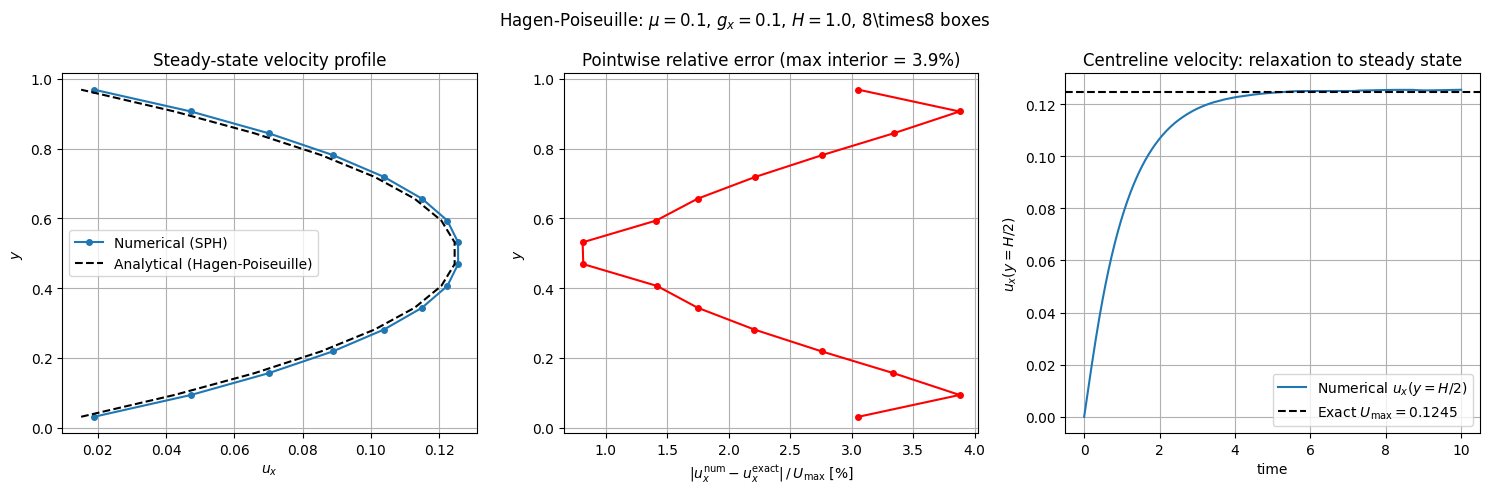

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- Left: velocity profile ---
ax = axes[0]
ax.plot(u_num_final, y_np, "o-", markersize=4, label="Numerical (SPH)")
ax.plot(u_exact,     y_np, "k--",              label="Analytical (Hagen-Poiseuille)")
ax.set_xlabel(r"$u_x$")
ax.set_ylabel(r"$y$")
ax.set_title("Steady-state velocity profile")
ax.legend()
ax.grid(True)

# --- Centre: pointwise relative error ---
ax = axes[1]
ax.plot(rel_err_pointwise * 100, y_np, "r-o", markersize=4)
ax.set_xlabel(r"$|u_x^\mathrm{num} - u_x^\mathrm{exact}|\,/\,U_\mathrm{max}$ [%]")
ax.set_ylabel(r"$y$")
ax.set_title(f"Pointwise relative error (max interior = {np.max(rel_error_interior)*100:.1f}%)")
ax.grid(True)

# --- Right: centreline velocity relaxation ---
ax = axes[2]
ax.plot(times, u_centre, label=r"Numerical $u_x(y=H/2)$")
ax.axhline(u_max_exact, color="k", linestyle="--",
           label=rf"Exact $U_\mathrm{{max}} = {u_max_exact:.4f}$")
ax.set_xlabel("time")
ax.set_ylabel(r"$u_x(y=H/2)$")
ax.set_title("Centreline velocity: relaxation to steady state")
ax.legend()
ax.grid(True)

fig.suptitle(
    rf"Hagen-Poiseuille: $\mu={mu}$, $g_x={g_x}$, $H={H}$, {nx}\times{nx} boxes",
    fontsize=12,
)
plt.tight_layout()
plt.show()

### Verification Check

Two assertions:
1. Maximum pointwise relative error in the **interior** bins (away from walls where the exact value vanishes) is below 5%.
2. Relative error in the peak velocity $U_\text{max}$ is below 5%.

In [9]:
tol_interior = 0.05   # 5% pointwise tolerance
tol_umax     = 0.05   # 5% tolerance on U_max

print("=== Hagen-Poiseuille Verification ===")
print(f"  Max interior relative error: {np.max(rel_error_interior) * 100:.2f}%  (tolerance {tol_interior*100:.0f}%)")
print(f"  U_max relative error:        {rel_error_umax * 100:.2f}%           (tolerance {tol_umax*100:.0f}%)")

try:
    assert np.max(rel_error_interior) < tol_interior, (
        f"Interior error {np.max(rel_error_interior)*100:.1f}% exceeds tolerance {tol_interior*100:.0f}%"
    )
    print("\n✓ Interior velocity profile check passed.")
except AssertionError as e:
    print(f"\n✗ {e}")

try:
    assert rel_error_umax < tol_umax, (
        f"U_max error {rel_error_umax*100:.1f}% exceeds tolerance {tol_umax*100:.0f}%"
    )
    print("✓ U_max check passed.")
except AssertionError as e:
    print(f"✗ {e}")

=== Hagen-Poiseuille Verification ===
  Max interior relative error: 3.88%  (tolerance 5%)
  U_max relative error:        0.82%           (tolerance 5%)

✓ Interior velocity profile check passed.
✓ U_max check passed.


### Conclusion

This tutorial verified the SPH discretisation of 2D viscous channel flow:

- The **no-slip boundary condition** is implemented via mirror ghost particles with negated tangential velocity, correctly enforcing $u_x = 0$ at both walls.
- The **parabolic steady state** emerges from the balance between body force and viscous stress, reproduced to better than 5% pointwise accuracy with $8 \times 8$ boxes and 16 particles per box.
- The **centreline velocity** converges smoothly to $U_\text{max}$ over the relaxation time $T_\text{relax} = H^2/(\pi^2 \mu) \approx 1$.
- Increasing `nx` or `ppb` further reduces the error, as the SPH kernel gradient approximation of the viscous stress tensor improves with particle density.

In [10]:
# Optional cleanup
if False:   # set to True to remove simulation output
    shutil.rmtree(test_folder)
    print(f"Cleaned up {test_folder}")